In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings, os, random, time
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset, random_split
from torch.optim.lr_scheduler import CosineAnnealingLR

from sklearn.metrics import mean_squared_error, mean_absolute_error

# ── Reproducibility ──────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {DEVICE}')
print(f'PyTorch: {torch.__version__}')

c:\Users\gtanu\anaconda3\lib\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


Device : cpu
PyTorch: 1.12.1


In [2]:
# ── Paths ─────────────────────────────────────────────────────────────────────
DATA_DIR   = 'C:\\IIoT-Predictive-Maintenance\\processed'   # folder containing *_tensors.npz
DATASET    = 'FD003'                    # FD001 | FD002 | FD003 | FD004

# ── Model hyper-parameters ───────────────────────────────────────────────────
GRU_HIDDEN   = 64      # hidden units per GRU layer
GRU_LAYERS   = 2      # stacked GRU layers
LSTM_HIDDEN  = 64     # hidden units per LSTM layer
LSTM_LAYERS  = 2      # stacked LSTM layers
FC_HIDDEN    = 32     # fully-connected hidden size
DROPOUT      = 0.3

# ── Training ─────────────────────────────────────────────────────────────────
BATCH_SIZE   = 256
EPOCHS       = 60
LR           = 1e-3
VAL_SPLIT    = 0.15    # fraction of train set used for validation
PATIENCE     = 10      # early-stopping patience (epochs without improvement)
MAX_RUL      = 125.0   # same cap used during preprocessing

In [3]:
npz = np.load(f'{DATA_DIR}/{DATASET}_tensors.npz')

X_train_np = npz['X_train'].astype(np.float32)   # (N, 30, 18)
y_train_np = npz['y_train'].astype(np.float32)   # (N,)
X_test_np  = npz['X_test'].astype(np.float32)    # (E, 30, 18)
y_test_np  = npz['y_test'].astype(np.float32)    # (E,)
feature_names = npz['feature_names'].tolist()

WIN  = X_train_np.shape[1]   # 30
FEAT = X_train_np.shape[2]   # 18

# Normalise RUL labels to [0,1] for stable training
y_train_norm = y_train_np / MAX_RUL
y_test_norm  = y_test_np  / MAX_RUL

print(f'Dataset    : {DATASET}')
print(f'X_train    : {X_train_np.shape}  (samples × window × features)')
print(f'X_test     : {X_test_np.shape}')
print(f'y_train    : min={y_train_np.min():.0f}  max={y_train_np.max():.0f}  mean={y_train_np.mean():.1f}')
print(f'y_test     : min={y_test_np.min():.0f}   max={y_test_np.max():.0f}   mean={y_test_np.mean():.1f}')
print(f'Features   : {feature_names}')

Dataset    : FD003
X_train    : (21820, 30, 18)  (samples × window × features)
X_test     : (100, 30, 18)
y_train    : min=0  max=125  mean=88.9
y_test     : min=6   max=125   mean=73.8
Features   : ['op_1', 'op_2', 'op_3', 's2', 's3', 's4', 's6', 's7', 's8', 's9', 's11', 's12', 's13', 's14', 's15', 's17', 's20', 's21']


In [4]:
X_tr = torch.from_numpy(X_train_np)
y_tr = torch.from_numpy(y_train_norm).unsqueeze(1)   # (N, 1)

full_ds  = TensorDataset(X_tr, y_tr)
val_size = int(len(full_ds) * VAL_SPLIT)
trn_size = len(full_ds) - val_size

trn_ds, val_ds = random_split(full_ds, [trn_size, val_size],
                               generator=torch.Generator().manual_seed(SEED))

trn_loader = DataLoader(trn_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

X_te = torch.from_numpy(X_test_np)
y_te = torch.from_numpy(y_test_norm).unsqueeze(1)
tst_loader = DataLoader(TensorDataset(X_te, y_te), batch_size=BATCH_SIZE, shuffle=False)

print(f'Train batches : {len(trn_loader)}  ({trn_size:,} samples)')
print(f'Val   batches : {len(val_loader)}  ({val_size:,} samples)')
print(f'Test  batches : {len(tst_loader)}  ({len(X_test_np)} engines)')

Train batches : 73  (18,547 samples)
Val   batches : 13  (3,273 samples)
Test  batches : 1  (100 engines)


In [5]:
class TemporalAttention(nn.Module):
    """Soft attention over the time dimension."""
    def __init__(self, hidden_dim: int):
        super().__init__()
        self.attn = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.Tanh(),
            nn.Linear(hidden_dim // 2, 1)
        )

    def forward(self, x):          # x: (B, T, H)
        scores  = self.attn(x)     # (B, T, 1)
        weights = torch.softmax(scores, dim=1)   # (B, T, 1)
        context = (weights * x).sum(dim=1)       # (B, H)
        return context, weights.squeeze(-1)       # weights returned for viz


class GRULSTM(nn.Module):
    """
    GRU  block  →  LSTM block  →  Temporal Attention  →  FC head
    
    The GRU extracts short-term local patterns while the LSTM encodes
    longer-range sequential dependencies. Attention then computes a
    weighted summary of the LSTM's hidden states for the regression head.
    """
    def __init__(self,
                 input_size:  int = FEAT,
                 gru_hidden:  int = GRU_HIDDEN,
                 gru_layers:  int = GRU_LAYERS,
                 lstm_hidden: int = LSTM_HIDDEN,
                 lstm_layers: int = LSTM_LAYERS,
                 fc_hidden:   int = FC_HIDDEN,
                 dropout:     float = DROPOUT):
        super().__init__()

        # ── GRU block ────────────────────────────────────────────────────
        self.gru = nn.GRU(
            input_size  = input_size,
            hidden_size = gru_hidden,
            num_layers  = gru_layers,
            batch_first = True,
            dropout     = dropout if gru_layers > 1 else 0.0,
            bidirectional = False
        )
        self.gru_drop = nn.Dropout(dropout)

        # ── LSTM block ───────────────────────────────────────────────────
        self.lstm = nn.LSTM(
            input_size  = gru_hidden,
            hidden_size = lstm_hidden,
            num_layers  = lstm_layers,
            batch_first = True,
            dropout     = dropout if lstm_layers > 1 else 0.0,
            bidirectional = False
        )
        self.lstm_drop = nn.Dropout(dropout)

        # ── Temporal attention ───────────────────────────────────────────
        self.attention = TemporalAttention(lstm_hidden)

        # ── Regression head ──────────────────────────────────────────────
        self.fc = nn.Sequential(
            nn.Linear(lstm_hidden, fc_hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(fc_hidden, 1),
            nn.Sigmoid()           # output in [0,1]; scale back by MAX_RUL
        )

    def forward(self, x, return_attn=False):
        # x: (B, T, F)
        gru_out,  _          = self.gru(x)          # (B, T, GRU_H)
        gru_out              = self.gru_drop(gru_out)
        lstm_out, _          = self.lstm(gru_out)   # (B, T, LSTM_H)
        lstm_out             = self.lstm_drop(lstm_out)
        context, attn_w      = self.attention(lstm_out)  # (B, LSTM_H)
        out                  = self.fc(context)          # (B, 1)
        if return_attn:
            return out, attn_w
        return out


model = GRULSTM().to(DEVICE)

# Parameter count
total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(model)
print(f'\nTotal parameters     : {total_params:,}')
print(f'Trainable parameters : {trainable_params:,}')

GRULSTM(
  (gru): GRU(18, 64, num_layers=2, batch_first=True, dropout=0.3)
  (gru_drop): Dropout(p=0.3, inplace=False)
  (lstm): LSTM(64, 64, num_layers=2, batch_first=True, dropout=0.3)
  (lstm_drop): Dropout(p=0.3, inplace=False)
  (attention): TemporalAttention(
    (attn): Sequential(
      (0): Linear(in_features=64, out_features=32, bias=True)
      (1): Tanh()
      (2): Linear(in_features=32, out_features=1, bias=True)
    )
  )
  (fc): Sequential(
    (0): Linear(in_features=64, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=32, out_features=1, bias=True)
    (4): Sigmoid()
  )
)

Total parameters     : 111,874
Trainable parameters : 111,874


In [6]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-5)

print(f'Loss      : MSELoss (labels normalised to [0,1])')
print(f'Optimiser : Adam  lr={LR}  weight_decay=1e-4')
print(f'Scheduler : CosineAnnealingLR  T_max={EPOCHS}  eta_min=1e-5')

Loss      : MSELoss (labels normalised to [0,1])
Optimiser : Adam  lr=0.001  weight_decay=1e-4
Scheduler : CosineAnnealingLR  T_max=60  eta_min=1e-5


In [7]:
def run_epoch(loader, train=True):
    model.train() if train else model.eval()
    total_loss = 0.0
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
            if train:
                optimizer.zero_grad()
            pred = model(X_batch)
            loss = criterion(pred, y_batch)
            if train:
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()
            total_loss += loss.item() * len(X_batch)
    return total_loss / len(loader.dataset)


history   = {'train_loss': [], 'val_loss': [], 'lr': []}
best_val  = float('inf')
patience_ctr = 0
best_state   = None

print(f"{'Epoch':>5}  {'Train MSE':>10}  {'Val MSE':>10}  {'RMSE(cyc)':>10}  {'LR':>8}")
print('-' * 55)

t0 = time.time()
for epoch in range(1, EPOCHS + 1):
    trn_loss = run_epoch(trn_loader, train=True)
    val_loss = run_epoch(val_loader, train=False)
    scheduler.step()
    cur_lr = scheduler.get_last_lr()[0]

    history['train_loss'].append(trn_loss)
    history['val_loss'].append(val_loss)
    history['lr'].append(cur_lr)

    # RMSE in original cycle units
    rmse_cycles = np.sqrt(val_loss) * MAX_RUL

    if epoch % 5 == 0 or epoch == 1:
        print(f"{epoch:>5}  {trn_loss:>10.6f}  {val_loss:>10.6f}  "
              f"{rmse_cycles:>9.2f}  {cur_lr:>8.2e}")

    # Early stopping
    if val_loss < best_val:
        best_val     = val_loss
        best_state   = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        patience_ctr = 0
    else:
        patience_ctr += 1
        if patience_ctr >= PATIENCE:
            print(f'\nEarly stop at epoch {epoch}  (best val MSE={best_val:.6f})')
            break

elapsed = time.time() - t0
print(f'\nTraining time : {elapsed:.1f}s')
print(f'Best val MSE  : {best_val:.6f}  → RMSE = {np.sqrt(best_val)*MAX_RUL:.2f} cycles')

# Restore best weights
model.load_state_dict(best_state)

Epoch   Train MSE     Val MSE   RMSE(cyc)        LR
-------------------------------------------------------
    1    0.120484    0.107082      40.90  9.99e-04
    5    0.022475    0.020115      17.73  9.83e-04
   10    0.017496    0.015218      15.42  9.34e-04
   15    0.015971    0.015427      15.53  8.55e-04
   20    0.014658    0.014589      15.10  7.53e-04
   25    0.013847    0.011854      13.61  6.33e-04
   30    0.013138    0.011015      13.12  5.05e-04
   35    0.013045    0.010795      12.99  3.77e-04
   40    0.012466    0.010722      12.94  2.58e-04
   45    0.012158    0.010461      12.79  1.55e-04
   50    0.011980    0.010006      12.50  7.63e-05
   55    0.011842    0.009987      12.49  2.69e-05
   60    0.011594    0.010054      12.53  1.00e-05

Training time : 12241.2s
Best val MSE  : 0.009924  → RMSE = 12.45 cycles


<All keys matched successfully>

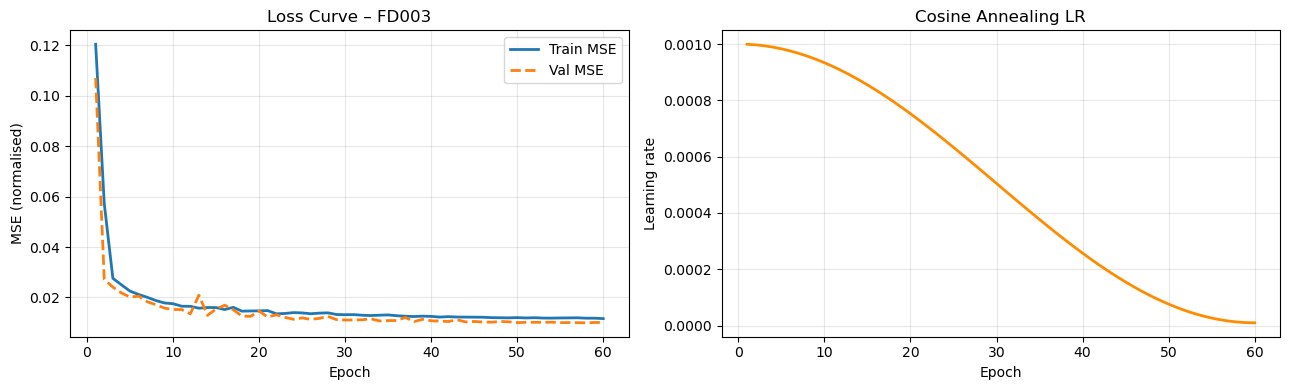

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

epochs_ran = range(1, len(history['train_loss']) + 1)

# Loss
ax = axes[0]
ax.plot(epochs_ran, history['train_loss'], label='Train MSE', lw=2)
ax.plot(epochs_ran, history['val_loss'],   label='Val MSE',   lw=2, linestyle='--')
ax.set_xlabel('Epoch');  ax.set_ylabel('MSE (normalised)')
ax.set_title(f'Loss Curve – {DATASET}');  ax.legend();  ax.grid(alpha=0.3)

# LR
ax = axes[1]
ax.plot(epochs_ran, history['lr'], color='darkorange', lw=2)
ax.set_xlabel('Epoch');  ax.set_ylabel('Learning rate')
ax.set_title('Cosine Annealing LR');  ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'C:\\IIoT-Predictive-Maintenance\\processed\\training_curves_{DATASET}.png', dpi=150, bbox_inches='tight')
plt.show()

In [9]:
model.eval()
preds_norm, trues_norm = [], []

with torch.no_grad():
    for X_batch, y_batch in tst_loader:
        out = model(X_batch.to(DEVICE)).cpu().numpy()
        preds_norm.append(out)
        trues_norm.append(y_batch.numpy())

preds_norm = np.concatenate(preds_norm).flatten()
trues_norm = np.concatenate(trues_norm).flatten()

# Scale back to cycle units
preds = preds_norm * MAX_RUL
trues = trues_norm * MAX_RUL

rmse = np.sqrt(mean_squared_error(trues, preds))
mae  = mean_absolute_error(trues, preds)
# NASA scoring function: S = Σ e^(d/13)-1 if d<0, e^(d/10)-1 if d≥0  where d = pred-true
d    = preds - trues
nasa_score = np.sum(np.where(d < 0, np.exp(-d/13) - 1, np.exp(d/10) - 1))

print('=' * 40)
print(f'  Dataset      : {DATASET}')
print(f'  Test engines : {len(preds)}')
print('-' * 40)
print(f'  RMSE         : {rmse:.2f} cycles')
print(f'  MAE          : {mae:.2f} cycles')
print(f'  NASA Score   : {nasa_score:.2f}  (lower = better)')
print('=' * 40)

  Dataset      : FD003
  Test engines : 100
----------------------------------------
  RMSE         : 14.23 cycles
  MAE          : 10.47 cycles
  NASA Score   : 381.67  (lower = better)


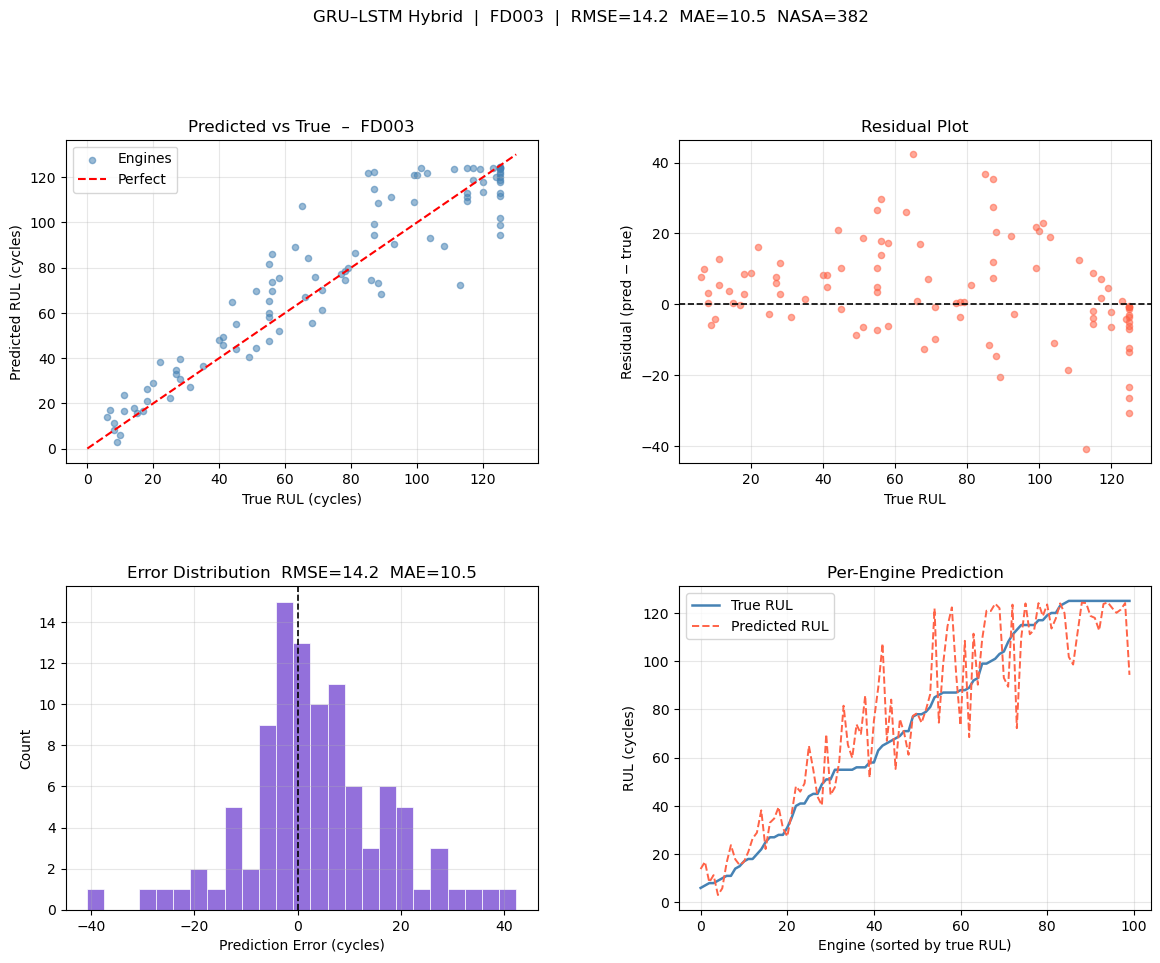

In [10]:
fig = plt.figure(figsize=(14, 10))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.38, wspace=0.3)

# ── (A) Predicted vs True scatter ────────────────────────────────────────────
ax = fig.add_subplot(gs[0, 0])
ax.scatter(trues, preds, alpha=0.55, s=20, color='steelblue', label='Engines')
lim = [0, MAX_RUL + 5]
ax.plot(lim, lim, 'r--', lw=1.5, label='Perfect')
ax.set_xlabel('True RUL (cycles)');  ax.set_ylabel('Predicted RUL (cycles)')
ax.set_title(f'Predicted vs True  –  {DATASET}');  ax.legend();  ax.grid(alpha=0.3)

# ── (B) Residuals ────────────────────────────────────────────────────────────
ax = fig.add_subplot(gs[0, 1])
residuals = preds - trues
ax.scatter(trues, residuals, alpha=0.55, s=20, color='tomato')
ax.axhline(0, color='k', lw=1.2, linestyle='--')
ax.set_xlabel('True RUL');  ax.set_ylabel('Residual (pred − true)')
ax.set_title('Residual Plot');  ax.grid(alpha=0.3)

# ── (C) Error distribution ───────────────────────────────────────────────────
ax = fig.add_subplot(gs[1, 0])
ax.hist(residuals, bins=25, color='mediumpurple', edgecolor='white', linewidth=0.5)
ax.axvline(0, color='k', lw=1.2, linestyle='--')
ax.set_xlabel('Prediction Error (cycles)');  ax.set_ylabel('Count')
ax.set_title(f'Error Distribution  RMSE={rmse:.1f}  MAE={mae:.1f}')
ax.grid(alpha=0.3)

# ── (D) Per-engine predictions sorted by true RUL ────────────────────────────
ax = fig.add_subplot(gs[1, 1])
idx = np.argsort(trues)
ax.plot(trues[idx],  label='True RUL',      lw=1.8, color='steelblue')
ax.plot(preds[idx],  label='Predicted RUL', lw=1.4, color='tomato', linestyle='--')
ax.set_xlabel('Engine (sorted by true RUL)');  ax.set_ylabel('RUL (cycles)')
ax.set_title('Per-Engine Prediction');  ax.legend();  ax.grid(alpha=0.3)

plt.suptitle(f'GRU–LSTM Hybrid  |  {DATASET}  |  RMSE={rmse:.1f}  MAE={mae:.1f}  NASA={nasa_score:.0f}',
             fontsize=12, y=1.01)
plt.savefig(f'C:\\IIoT-Predictive-Maintenance\\processed\\evaluation_plots_{DATASET}.png', dpi=150, bbox_inches='tight')
plt.show()

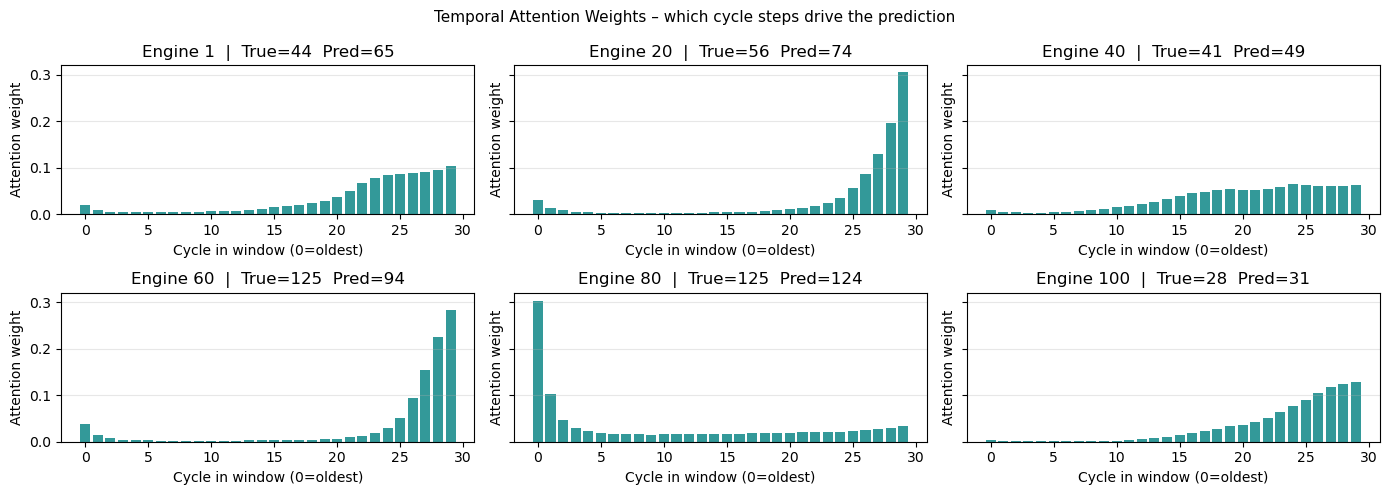

In [11]:
# Inspect attention weights for 6 test engines
model.eval()
sample_idx = np.linspace(0, len(X_test_np)-1, 6, dtype=int)
X_sample   = torch.from_numpy(X_test_np[sample_idx]).to(DEVICE)

with torch.no_grad():
    _, attn_weights = model(X_sample, return_attn=True)  # (6, 30)
attn_weights = attn_weights.cpu().numpy()

fig, axes = plt.subplots(2, 3, figsize=(14, 5), sharey=True)
for i, ax in enumerate(axes.flat):
    eng_idx = sample_idx[i]
    ax.bar(range(WIN), attn_weights[i], color='teal', alpha=0.8)
    ax.set_title(f'Engine {eng_idx+1}  |  True={trues[eng_idx]:.0f}  Pred={preds[eng_idx]:.0f}')
    ax.set_xlabel('Cycle in window (0=oldest)')
    ax.set_ylabel('Attention weight')
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Temporal Attention Weights – which cycle steps drive the prediction', fontsize=11)
plt.tight_layout()
plt.savefig(f'C:\\IIoT-Predictive-Maintenance\\processed\\attention_weights_{DATASET}.png', dpi=150, bbox_inches='tight')
plt.show()